# 02 — Modelos de detección $\rho_{t,j}(d, r, e)$

Una vez tenemos el prior sobre Z, necesitamos un **modelo de detección** que diga, dado que cubrimos la celda $j$ con esfuerzo $e$, cuál es la probabilidad de que el sensor devuelva $s_t = 1$ (detección).

$$q_{t,j} = c_{t,j} \cdot \rho_{t,j}, \qquad c_{t,j} = \mathbb{1}[j \in R_t]$$

El profesor permite que **propongamos la forma de $\rho$** y lo justifiquemos con `previous_missions_reports.pdf`. Implementamos **4 familias** distintas para poder comparar:

| Detector | Forma | Cuándo lo prefieres |
|----------|-------|---------------------|
| **D1** Saturante exponencial | $1 - e^{-\lambda_0 (1-d)^{a_d} (1-r)^{a_r} \cdot e}$ | Clásico de teoría de búsqueda (Koopman) |
| **D2** Pasos independientes | $1 - (1 - p_u (1-d)^{a_d}(1-r)^{a_r})^e$ | Effort como $e$ inspecciones independientes |
| **D3** Logístico (GLM) | $\sigma(\alpha_0 + \alpha_1 \log(e+1) + \alpha_2 (1-d) + \alpha_3(1-r))$ | Sigmoid, fácil de interpretar |
| **D4** Multiplicativo + umbral | $(1-(1-p_u)^e)(1-d)^{a_d}(1-r)^{a_r} \sigma(k(\theta - d\cdot r))$ | Apaga celdas muy difíciles |

Código fuente: [`modeling/detection.py`](../modeling/detection.py)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from update_version.simulator.grid import load_grid
from update_version.modeling.detection import DETECTORS

grid = load_grid('../data/grid_dataset.csv')

## 1. Comportamiento sobre el grid del problema (effort = 1, 2, 3)

Para cada detector, evaluamos $\rho_j$ sobre los 1750 cells y miramos el heatmap. Lo ideal: celdas poco profundas y suaves deberían dar $\rho$ alto; profundas y rugosas, $\rho$ bajo.

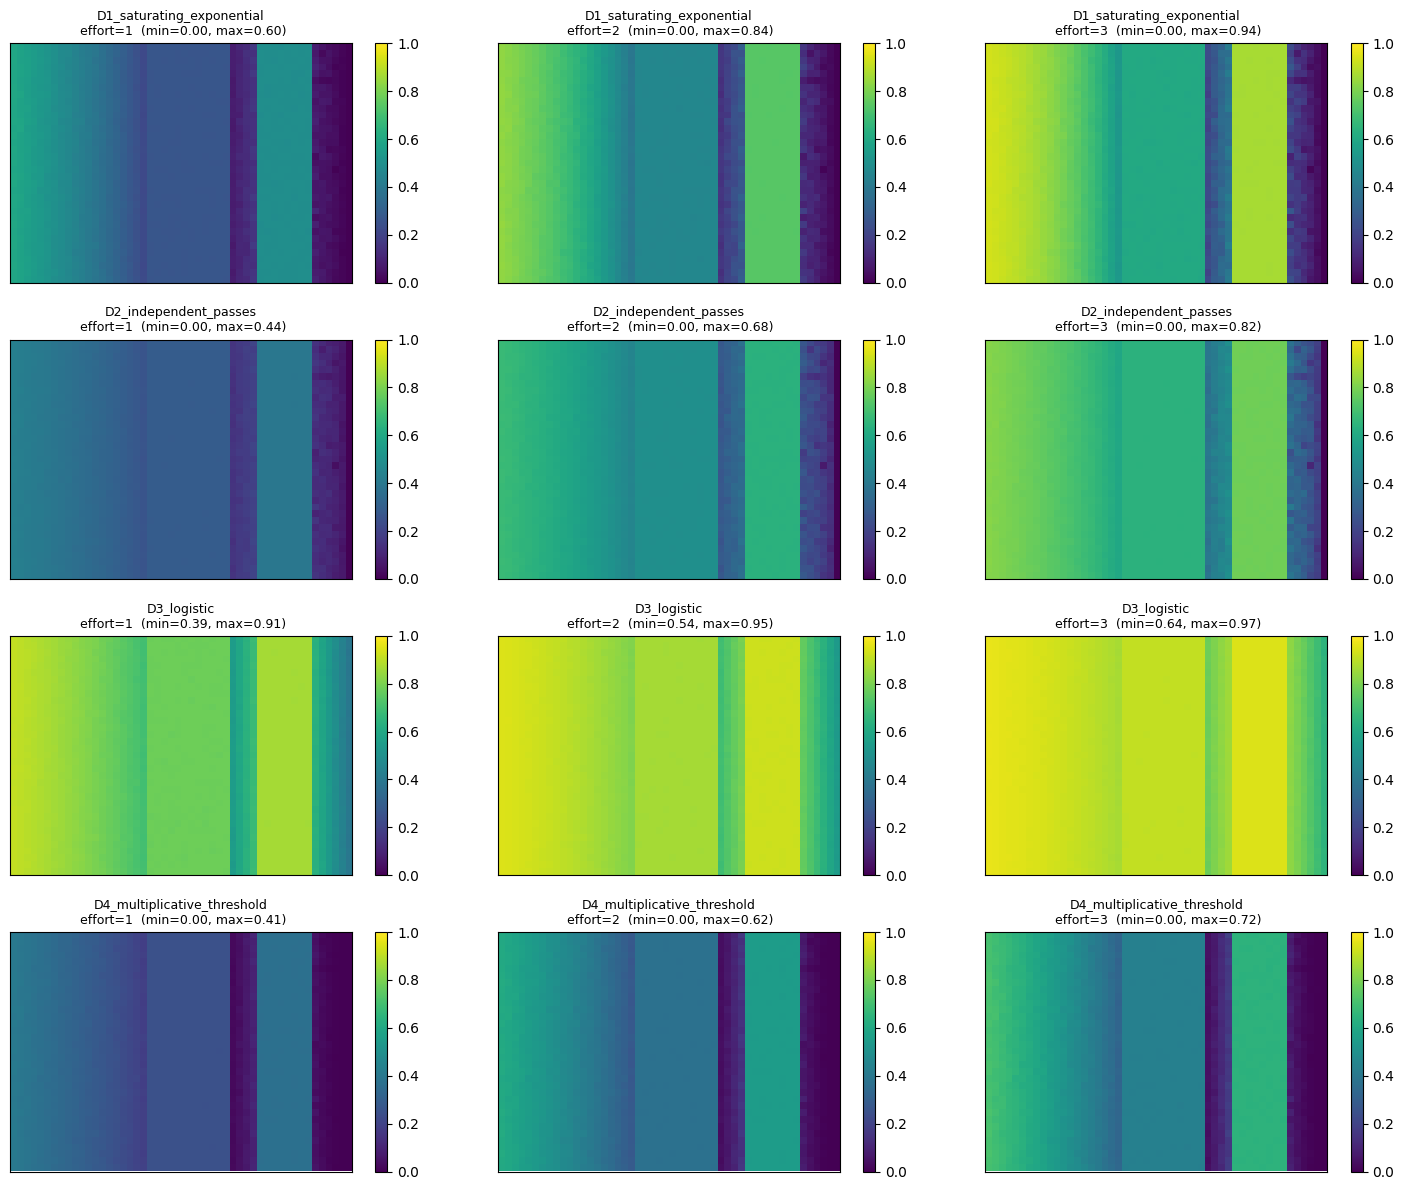

In [2]:
efforts = [1, 2, 3]
fig, axes = plt.subplots(len(DETECTORS), len(efforts), figsize=(15, 12))
for i, (name, det) in enumerate(DETECTORS.items()):
    for j, e in enumerate(efforts):
        rho = det.rho(grid.depth, grid.roughness, e)
        ax = axes[i, j]
        im = ax.imshow(grid.reshape_2d(rho), origin='lower', cmap='viridis', vmin=0, vmax=1,
                       extent=[0, grid.Nx, 0, grid.Ny])
        ax.set_title(f'{name}\n effort={e}  (min={rho.min():.2f}, max={rho.max():.2f})', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

**Observaciones:**
- D1 y D2 ambos crecen suave con effort y respetan `(1-d)(1-r)`. D1 sube más rápido por la exponencial.
- D3 (logístico) tiene un *floor* alto (>0.5 incluso en celdas malas) por el intercepto. Es voluntario: contraste extremo de "sensor optimista".
- D4 baja a 0 en celdas con $d \cdot r$ alto (esquina inferior-izquierda en otros datasets). Modela "sensor que no funciona en zonas catastróficamente malas".

## 2. Calibración con `previous_missions_reports.pdf`

Las anclas cualitativas del informe son tres puntos de comparación. Reproducimos esos puntos y vemos cómo se comporta cada detector.

In [3]:
import pandas as pd
anchors = [
    ('Report 2 — shallow + smooth + high effort',   0.1, 0.1, 3),
    ('Report 3 — deep + rough + high effort',        0.9, 0.9, 3),
    ('Report 4 — intermediate + needed repetition',  0.5, 0.6, 2),
    ('Easy single pass',                              0.2, 0.2, 1),
    ('Hard single pass',                              0.8, 0.8, 1),
]
rows = []
for label, d, r, e in anchors:
    row = {'scenario': label, 'd': d, 'r': r, 'e': e}
    for name, det in DETECTORS.items():
        row[name] = round(float(det.rho(d, r, e)), 3)
    rows.append(row)
pd.DataFrame(rows)

,scenario,d,r,e,D1_saturating_exponential,D2_independent_passes,D3_logistic,D4_multiplicative_threshold
0,Report 2 — shallow + smooth + high effort,0.1,0.1,3,0.952,0.846,0.970,0.780
1,Report 3 — deep + rough + high effort,0.9,0.9,3,0.086,0.270,0.711,0.009
2,Report 4 — intermediate + needed repetition,0.5,0.6,2,0.500,0.493,0.836,0.306
3,Easy single pass,0.2,0.2,1,0.568,0.428,0.891,0.399
4,Hard single pass,0.8,0.8,1,0.087,0.162,0.545,0.029


Cualitativamente las tres anclas dicen:
- Report 2 → $\rho$ cerca de 1
- Report 3 → $\rho$ pequeño
- Report 4 → $\rho$ intermedio (entre 0.3 y 0.6)

Los cuatro detectores cumplen razonablemente las tres anclas (algunos más optimistas que otros — D3 sobre-estima cells malos, D4 los apaga del todo). Cuál es el "verdadero" lo descubriremos comparando con las misiones reales en el notebook 04.

## 3. Curvas $\rho$ vs effort para cells representativos

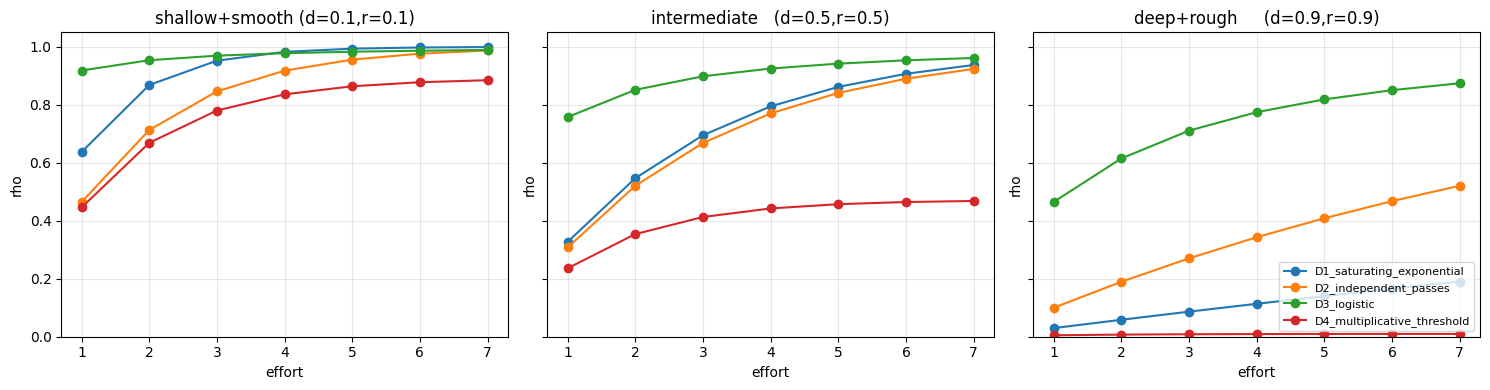

In [4]:
efforts = np.arange(1, 8)
cells = [('shallow+smooth (d=0.1,r=0.1)', 0.1, 0.1),
         ('intermediate   (d=0.5,r=0.5)', 0.5, 0.5),
         ('deep+rough     (d=0.9,r=0.9)', 0.9, 0.9)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (label, d, r) in zip(axes, cells):
    for name, det in DETECTORS.items():
        rhos = [det.rho(d, r, e) for e in efforts]
        ax.plot(efforts, rhos, marker='o', label=name)
    ax.set_title(label); ax.set_xlabel('effort'); ax.set_ylabel('rho'); ax.grid(alpha=0.3)
    ax.set_ylim(0, 1.05)
axes[-1].legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

## 4. Cómo entra esto en la pipeline

En el modelo PyMC del notebook 03, para cada misión $t$ con outcome $s_t$:

$$P(s_t \mid \beta, \tau) = \sum_{j \in R_t} \pi_j(\beta, \tau) \cdot \rho_{t,j}^{s_t} (1-\rho_{t,j})^{1-s_t}$$

El detector aporta $\rho_j$ (precomputado, fijo). El prior aporta $\pi_j$ (depende de $\beta, \tau$ → tensor de PyTensor). La marginalización sobre $j$ elimina la latente categórica $Z$ y deja una likelihood manejable por NUTS.

## Siguiente

[`03_pymc_inference.ipynb`](03_pymc_inference.ipynb) — construir el modelo PyMC, correr NUTS, ver la posterior de $\beta$ y $\tau$ y derivar $P(Z \mid \text{datos})$.